In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

np.random.seed(42)


class DenseLayer:
    def __init__(self, units=1, activation='relu'):
        self.units = units
        self.activation = activation.lower()
        self.w = None
        self.b = None
        self.input = None
        self.z = None

    def init_weights(self, fan_in):
        if self.activation in ['relu', 'leaky_relu']:
            std = np.sqrt(2.0 / fan_in)
        else:
            std = np.sqrt(1.0 / fan_in)

        self.w = np.random.normal(0.0, std, (fan_in, self.units))
        self.b = np.zeros(self.units)

    def forward(self, x):
        if self.w is None:
            self.init_weights(x.shape[-1])

        self.z = x @ self.w + self.b

        if self.activation == 'relu':
            return np.maximum(0, self.z)

        elif self.activation == 'leaky_relu':
            return np.maximum(0.01 * self.z, self.z)

        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(self.z, -500, 500)))

        elif self.activation == 'tanh':
            return np.tanh(self.z)

        elif self.activation == 'softmax':
            exp_z = np.exp(self.z - np.max(self.z, axis=1, keepdims=True))
            return exp_z / np.sum(exp_z, axis=1, keepdims=True)

        elif self.activation == 'linear':
            return self.z

        else:
            raise ValueError(f"Неизвестная активация: {self.activation}")

    def derivative(self, a):
        if self.activation == 'relu':
            return (self.z > 0).astype(float)

        elif self.activation == 'leaky_relu':
            return (self.z > 0).astype(float) + 0.01 * (self.z <= 0).astype(float)

        elif self.activation == 'sigmoid':
            return a * (1 - a)

        elif self.activation == 'tanh':
            return 1 - a**2

        elif self.activation == 'linear':
            return np.ones_like(a)

        elif self.activation == 'softmax':
            return np.ones_like(a)

        return np.ones_like(a)


class Input:
    def __init__(self, shape=None):
        self.shape = shape

    def forward(self, x):
        if self.shape is not None:
            expected = self.shape if isinstance(self.shape, tuple) else (self.shape,)
            if x.shape[1:] != expected:
                x = x.reshape((x.shape[0],) + expected)
        return x


class Dropout:
    def __init__(self, rate=0.5):
        self.rate = rate
        self.mask = None
        self.training = True

    def forward(self, x):
        if not self.training:
            return x
        self.mask = (np.random.rand(*x.shape) > self.rate) / (1 - self.rate)
        return x * self.mask


class Sequential:
    def __init__(self, layers):
        self.layers = layers
        self.history = []
        self.loss_fn = None
        self.loss_deriv = None
        self.l1 = 0
        self.l2 = 0

    def compile(self, loss='mse', l1=0.0, l2=0.0):
        self.l1 = l1
        self.l2 = l2
        self.loss = loss.lower()

        if self.loss == 'mse':
            self.loss_fn = lambda y, p: 0.5 * np.sum((p - y) ** 2)
            self.loss_deriv = lambda y, p: (p - y)

        elif self.loss == 'mae':
            self.loss_fn = lambda y, p: np.mean(np.abs(p - y))
            self.loss_deriv = lambda y, p: np.sign(p - y)

        elif self.loss == 'binary_crossentropy':
            eps = 1e-8
            self.loss_fn = lambda y, p: -np.mean(
                y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)
            )
            self.loss_deriv = lambda y, p: (p - y) / np.clip(p * (1.0 - p), eps, None)

        elif self.loss == 'categorical_crossentropy':
            eps = 1e-8
            self.loss_fn = lambda y, p: -np.mean(np.sum(y * np.log(p + eps), axis=1))
            self.loss_deriv = lambda y, p: (p - y)

        else:
            raise ValueError(f"Неизвестная функция потерь: {loss}")

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def fit(self, x_input, y_input, epochs=100, alpha=0.001, batch_size=32,
            clip_value=5.0, adaptive_alpha=False, Ee=1e-3, verbose=True):
        x_input = np.asarray(x_input, dtype=np.float32)
        y_input = np.asarray(y_input, dtype=np.float32).reshape(-1, 1)

        n_samples = x_input.shape[0]
        self.history = []

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            x_shuffled = x_input[indices]
            y_shuffled = y_input[indices]

            for i in range(0, n_samples, batch_size):
                x = x_shuffled[i:i + batch_size]
                y = y_shuffled[i:i + batch_size]

                if adaptive_alpha:
                    alpha_t = 1.0 / (1 + np.sum(x ** 2))
                else:
                    alpha_t = alpha

                activations = [x]
                for layer in self.layers:
                    if isinstance(layer, Dropout):
                        layer.training = True
                    activations.append(layer.forward(activations[-1]))

                pred = activations[-1]
                delta = self.loss_deriv(y, pred)

                for l in range(len(self.layers) - 1, -1, -1):
                    layer = self.layers[l]

                    if isinstance(layer, Input):
                        continue

                    if isinstance(layer, Dropout):
                        delta *= layer.mask
                        continue

                    a_prev = activations[l]
                    da = layer.derivative(activations[l + 1])
                    delta *= da

                    grad_w = (a_prev.T @ delta) / x.shape[0]
                    grad_b = np.mean(delta, axis=0)

                    if self.l2:
                        grad_w += 2 * self.l2 * layer.w
                    if self.l1:
                        grad_w += self.l1 * np.sign(layer.w)

                    grad_w = np.clip(grad_w, -clip_value, clip_value)
                    grad_b = np.clip(grad_b, -clip_value, clip_value)

                    previous_delta = delta @ layer.w.T
                    layer.w -= alpha_t * grad_w
                    layer.b -= alpha_t * grad_b
                    delta = previous_delta

            epoch_loss = self.loss_fn(y_input, self.predict(x_input))
            self.history.append(epoch_loss)

            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:4d} | Es = {epoch_loss:.6f}")

            if epoch_loss <= Ee:
                if verbose:
                    print(f"Достигнут критерий остановки: {epoch_loss} <= {Ee}")
                return epoch + 1, True

        return epochs, False

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.training = False

        return self.forward(X)

    def evaluate(self, X, Y):
        Y = np.asarray(Y, dtype=np.float32).reshape(-1, 1)
        preds = self.predict(X)
        loss = self.loss_fn(Y, preds) if self.loss_fn is not None else None

        last_activation = getattr(self.layers[-1], "activation", None)
        if last_activation == "sigmoid":
            y_hat = (preds >= 0.5).astype(np.float32)
            acc = np.mean(y_hat == Y)
        else:
            acc = None

        return loss, acc

## Данные варианта 7 и вспомогательные функции

Нормализация меток $c_0, c_1 \to 0/1$ и обратный пересчёт $\hat{y} \to [c_0; c_1]$.

In [ ]:
c0, c1 = -4.0, -9.0
x = np.array([[c0, c0], [c0, c1], [c1, c0], [c1, c1]], dtype=np.float32)
y = np.array([-4, -9, -9, -4], dtype=np.float32)

x_norm = (x - c0) / (c1 - c0)
y_norm = np.array([0, 1, 1, 0], dtype=np.float32)

MAX_EPOCHS = 1500
ALPHA = 0.5
BATCH_SIZE = 1
EE_MSE = 0.01
EE_BCE = 0.01
SEEDS = [42, 7, 13, 21, 99]
PLOTS_DIR = Path.cwd() / "plots"


def _save_and_maybe_show(fig, path):
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def denormalize_output(y_hat):
    return c0 + np.asarray(y_hat) * (c1 - c0)


def normalize_inputs(X):
    return (np.asarray(X, dtype=np.float32) - c0) / (c1 - c0)


def build_mlp():
    return Sequential([
        Input(),
        DenseLayer(units=2, activation="sigmoid"),
        DenseLayer(units=1, activation="sigmoid"),
    ])


def classification_from_real(y_real):
    y_real = np.asarray(y_real).reshape(-1)
    d0 = np.abs(y_real - c0)
    d1 = np.abs(y_real - c1)
    return np.where(d0 <= d1, c0, c1)


def metrics_on_truth_table(model, from_normalized=True):
    preds = model.predict(x_norm).reshape(-1)
    y_real_hat = denormalize_output(preds) if from_normalized else preds
    y_true = y.reshape(-1)
    pred_cls = classification_from_real(y_real_hat)
    acc = float(np.mean(pred_cls == y_true))
    mae = float(np.mean(np.abs(y_real_hat - y_true)))
    return preds, y_real_hat, acc, mae


def train_one(loss, seed, y_targets, Ee, verbose=False):
    np.random.seed(seed)
    model = build_mlp()
    model.compile(loss=loss)
    n_epochs, converged = model.fit(
        x_norm, y_targets,
        epochs=MAX_EPOCHS,
        alpha=ALPHA,
        batch_size=BATCH_SIZE,
        Ee=Ee,
        verbose=verbose,
    )
    final_es = float(model.history[-1]) if model.history else float("nan")
    _, _, acc, mae = metrics_on_truth_table(model, from_normalized=True)
    return {
        "seed": seed,
        "model": model,
        "epochs": n_epochs,
        "converged": converged,
        "Es": final_es,
        "accuracy": acc,
        "mae": mae,
        "history": list(model.history),
        "Ee": Ee,
        "loss": loss,
    }


def print_run_table(title, runs):
    print(f"\n{title}")
    print(f"{'seed':>6} | {'эпохи':>7} | {'сходимость':>11} | {'Es':>10} | "
          f"{'acc':>6} | {'MAE [c0;c1]':>12}")
    print("-" * 72)
    for r in runs:
        flag = "да" if r["converged"] else "нет"
        print(f"{r['seed']:6d} | {r['epochs']:7d} | {flag:>11} | {r['Es']:10.6f} | "
              f"{r['accuracy']:6.2f} | {r['mae']:12.4f}")
    n_ok = sum(1 for r in runs if r["converged"])
    epochs_ok = [r["epochs"] for r in runs if r["converged"]]
    print(f"Сходимость: {n_ok}/5 запусков", end="")
    if epochs_ok:
        print(f", эпохи: min={min(epochs_ok)}, max={max(epochs_ok)}, "
              f"mean={np.mean(epochs_ok):.1f}, std={np.std(epochs_ok):.1f}")
    else:
        print(", ни один запуск не достиг Ee")


def pick_representative(runs):
    """Предпочтительный запуск: seed=42, если сошёлся, иначе первый успешный."""
    for r in runs:
        if r["seed"] == 42 and r["converged"]:
            return r
    for r in runs:
        if r["converged"]:
            return r
    return runs[0]


def plot_convergence(run_a, run_b, path):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(run_a["history"], label="Конфигурация А (MSE)", color="tab:blue", lw=2)
    ax.plot(run_b["history"], label="Конфигурация Б (BCE)", color="tab:orange", lw=2)
    ax.axhline(run_a["Ee"], color="tab:blue", ls="--", alpha=0.7,
               label=f"Ee MSE = {run_a['Ee']}")
    ax.axhline(run_b["Ee"], color="tab:orange", ls=":", alpha=0.7,
               label=f"Ee BCE = {run_b['Ee']}")
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Суммарная ошибка Es")
    ax.set_title("Сходимость: Es от номера эпохи (представительные запуски)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    _save_and_maybe_show(fig, path)
    return fig


def plot_epochs_spread(runs_a, runs_b, path):
    fig, ax = plt.subplots(figsize=(9, 5))
    idx = np.arange(len(SEEDS))
    width = 0.35
    epochs_a = [r["epochs"] for r in runs_a]
    epochs_b = [r["epochs"] for r in runs_b]
    bars_a = ax.bar(idx - width / 2, epochs_a, width, label="А (MSE)", color="tab:blue")
    bars_b = ax.bar(idx + width / 2, epochs_b, width, label="Б (BCE)", color="tab:orange")

    for bars, runs in ((bars_a, runs_a), (bars_b, runs_b)):
        for bar, run in zip(bars, runs):
            if not run["converged"]:
                bar.set_hatch("//")
                bar.set_alpha(0.55)

    ax.set_xticks(idx)
    ax.set_xticklabels([str(s) for s in SEEDS])
    ax.set_xlabel("seed")
    ax.set_ylabel("Число эпох")
    ax.set_title("Разброс числа эпох по 5 запускам")
    ax.legend(handles=[
        Patch(facecolor="tab:blue", label="А (MSE)"),
        Patch(facecolor="tab:orange", label="Б (BCE)"),
        Patch(facecolor="0.8", edgecolor="black", hatch="//", label="Ee не достигнут"),
    ])
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    _save_and_maybe_show(fig, path)
    return fig


def plot_decision_and_mae(run_a, run_b, path):
    grid = np.linspace(-10, 10, 201)
    xx, yy = np.meshgrid(grid, grid)
    pts = np.c_[xx.ravel(), yy.ravel()]
    pts_n = normalize_inputs(pts)

    zz_a = run_a["model"].predict(pts_n).reshape(xx.shape)
    zz_b = run_b["model"].predict(pts_n).reshape(xx.shape)
    surfaces = [
        (zz_a, "А (MSE): выход сети ŷ ∈ (0; 1)"),
        (zz_b, "Б (BCE): выход сети ŷ ∈ (0; 1)"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, (zz, title) in zip(axes[0], surfaces):
        im = ax.contourf(xx, yy, zz, levels=40, cmap="coolwarm", vmin=0.0, vmax=1.0)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ŷ")
        mask0 = y.reshape(-1) == c0
        ax.scatter(x[mask0, 0], x[mask0, 1], c="tab:blue", edgecolors="black",
                   s=90, zorder=5, label=f"класс c0={c0:g}")
        ax.scatter(x[~mask0, 0], x[~mask0, 1], c="tab:red", edgecolors="black",
                   s=90, zorder=5, label=f"класс c1={c1:g}")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.set_xlabel("A")
        ax.set_ylabel("B")
        ax.set_title(title)
        ax.set_aspect("equal")

    ax_mae = axes[1, 0]
    ax_mae.bar(["А (MSE)", "Б (BCE)"], [run_a["mae"], run_b["mae"]],
               color=["tab:blue", "tab:orange"])
    ax_mae.set_ylabel("MAE")
    ax_mae.set_title("Средняя абсолютная ошибка в шкале [c0; c1]")
    ax_mae.grid(True, axis="y", alpha=0.3)

    ax_acc = axes[1, 1]
    ax_acc.bar(["А (MSE)", "Б (BCE)"], [run_a["accuracy"], run_b["accuracy"]],
               color=["tab:blue", "tab:orange"])
    ax_acc.set_ylim(0.0, 1.05)
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title("Accuracy на 4 примерах таблицы истинности")
    ax_acc.grid(True, axis="y", alpha=0.3)

    fig.suptitle("Разделяющая поверхность и точность восстановления шкалы", y=1.01)
    fig.tight_layout()
    _save_and_maybe_show(fig, path)
    return fig


def describe_inference(model, A, B, tag=""):
    A, B = float(A), float(B)
    y_hat = float(model.predict(normalize_inputs([[A, B]]))[0, 0])
    y_real = float(denormalize_output(y_hat))
    pred_cls = float(classification_from_real(y_real)[0])
    prefix = f"{tag} " if tag else ""
    print(f"{prefix}(A, B) = ({A:g}, {B:g})  ->  "
          f"ŷ = {y_hat:.4f},  y_real = {y_real:.4f},  класс = {pred_cls:g}")
    return y_hat, y_real, pred_cls


def run_inference_demo(model_a, model_b):
    extra = [(0.0, 0.0), (-10.0, 10.0), (-6.5, -6.5)]
    print("\nРежим функционирования (представительные сети А и Б)")
    print("Обучающая выборка (таблица истинности):")
    for (A, B), t in zip(x, y):
        print(f"  истинный класс = {t:g}")
        describe_inference(model_a, A, B, tag="    A")
        describe_inference(model_b, A, B, tag="    B")
    print("Дополнительные пары вне обучающей выборки:")
    for A, B in extra:
        describe_inference(model_a, A, B, tag="    A")
        describe_inference(model_b, A, B, tag="    B")


def interactive_mode(model):
    print("\nИнтерактивный режим (конфигурация Б). Введите A B из [-10; 10] "
          "или q для выхода.")
    while True:
        raw = input("A B > ").strip()
        if raw.lower() in {"q", "quit", "exit"}:
            break
        parts = raw.replace(",", " ").split()
        if len(parts) != 2:
            print("Нужно два числа A и B.")
            continue
        try:
            A, B = float(parts[0]), float(parts[1])
        except ValueError:
            print("Не удалось разобрать числа.")
            continue
        if min(A, B) < -10 or max(A, B) > 10:
            print("A и B должны быть в диапазоне [-10; 10].")
            continue
        describe_inference(model, A, B)


print(f"c0={c0}, c1={c1}")
print("Таблица истинности (A, B) -> XOR:")
for (A, B), t, t01 in zip(x, y, y_norm):
    print(f"  ({A:5.1f}, {B:5.1f}) -> {t:5.1f}  (метка 0/1 = {int(t01)})")
print(f"alpha={ALPHA}, batch_size={BATCH_SIZE}, max_epochs={MAX_EPOCHS}")
print(f"Ee_MSE={EE_MSE}, Ee_BCE={EE_BCE}, seeds={SEEDS}")

c0=-4.0, c1=-9.0
Таблица истинности (A, B) -> XOR:
  ( -4.0,  -4.0) ->  -4.0  (метка 0/1 = 0)
  ( -4.0,  -9.0) ->  -9.0  (метка 0/1 = 1)
  ( -9.0,  -4.0) ->  -9.0  (метка 0/1 = 1)
  ( -9.0,  -9.0) ->  -4.0  (метка 0/1 = 0)
alpha=0.5, batch_size=1, max_epochs=1500
Ee_MSE=0.01, Ee_BCE=0.01, seeds=[42, 7, 13, 21, 99]


## Обучение двух конфигураций

Вариант 7: c0 = -4, c1 = -9
Конфигурация А: MLP 2-2-1, MSE, метки 0/1 (сигмоида), затем [c0; c1]
Конфигурация Б: MLP 2-2-1, BCE, метки 0/1, затем пересчёт в [c0; c1]
Онлайн-обучение (batch_size=1), alpha=0.5, max_epochs=1500, Ee_MSE=0.01, Ee_BCE=0.01

--- Серия запусков: конфигурация А (MSE) ---

Конфигурация А (MSE)
  seed |   эпохи |  сходимость |         Es |    acc |  MAE [c0;c1]
------------------------------------------------------------------------
    42 |    1500 |         нет |   0.023049 |   1.00 |       0.5301
     7 |    1500 |         нет |   0.011238 |   1.00 |       0.3703
    13 |    1494 |          да |   0.009993 |   1.00 |       0.3506
    21 |    1411 |          да |   0.009996 |   1.00 |       0.3521
    99 |    1500 |         нет |   0.349229 |   0.75 |       1.9029
Сходимость: 2/5 запусков, эпохи: min=1411, max=1494, mean=1452.5, std=41.5

--- Серия запусков: конфигурация Б (BCE) ---

Конфигурация Б (BCE)
  seed |   эпохи |  сходимость |         Es |    acc |  M

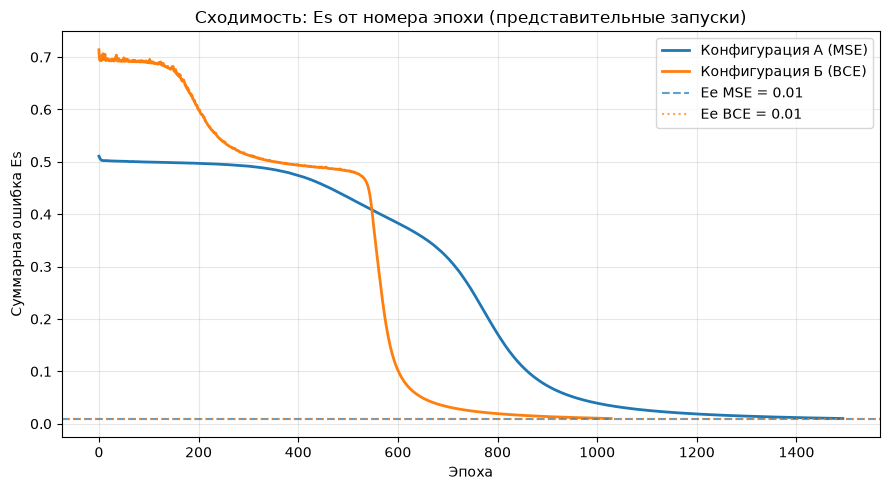

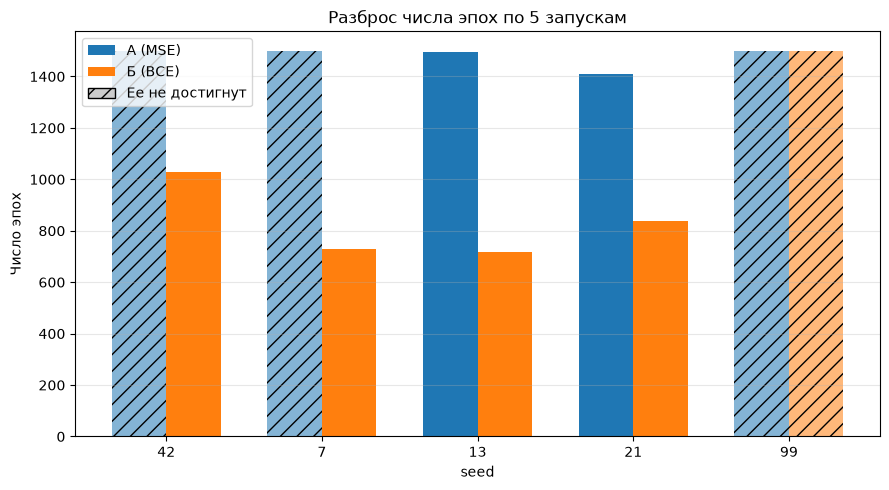

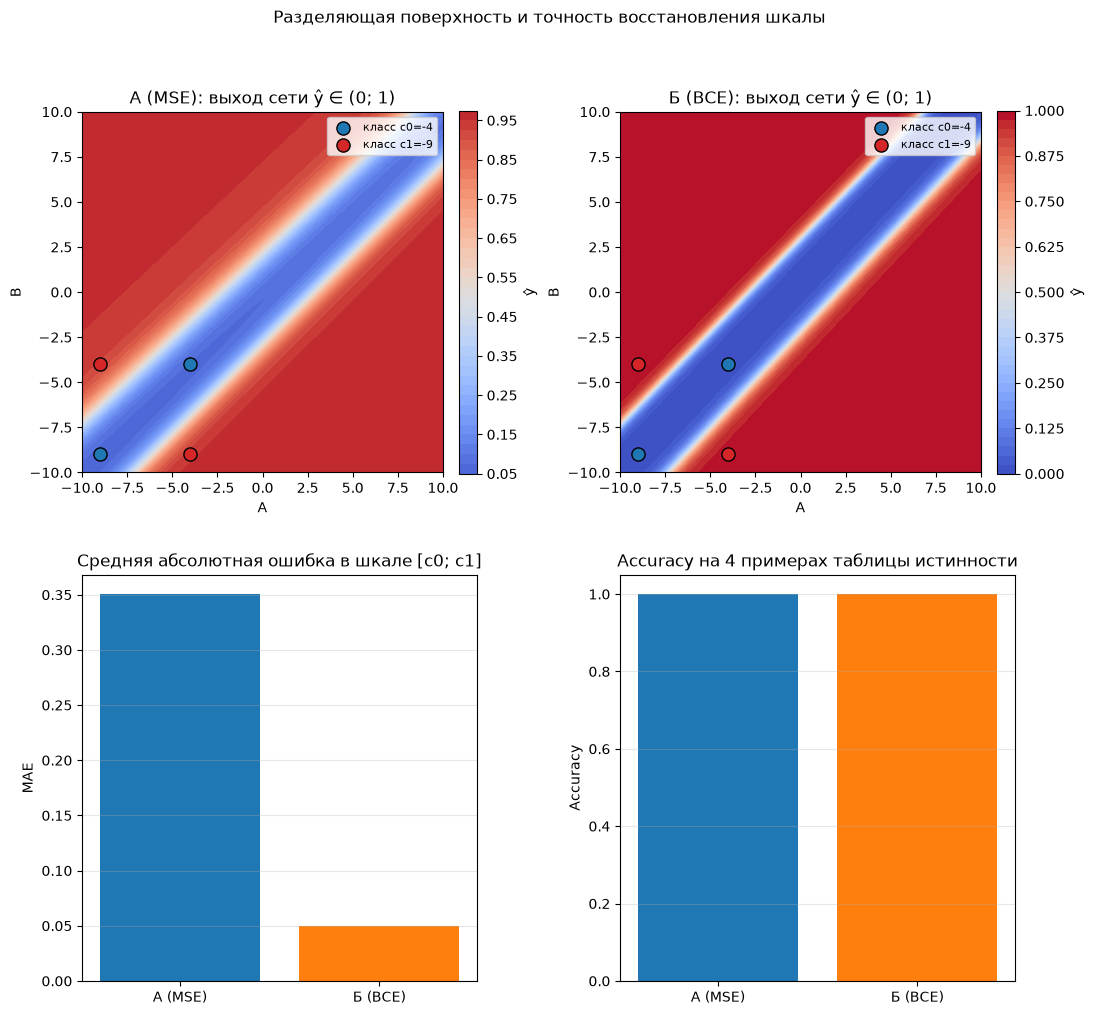


Графики сохранены в /home/asgaroth/University/4 курс/МРЗвИС/MRZvIS_II26/reports/Ковальчук Артём/Lab 2/src/plots

Режим функционирования (представительные сети А и Б)
Обучающая выборка (таблица истинности):
  истинный класс = -4
    A (A, B) = (-4, -4)  ->  ŷ = 0.0713,  y_real = -4.3566,  класс = -4
    B (A, B) = (-4, -4)  ->  ŷ = 0.0095,  y_real = -4.0473,  класс = -4
  истинный класс = -9
    A (A, B) = (-4, -9)  ->  ŷ = 0.9374,  y_real = -8.6872,  класс = -9
    B (A, B) = (-4, -9)  ->  ŷ = 0.9860,  y_real = -8.9301,  класс = -9
  истинный класс = -9
    A (A, B) = (-9, -4)  ->  ŷ = 0.9158,  y_real = -8.5788,  класс = -9
    B (A, B) = (-9, -4)  ->  ŷ = 0.9919,  y_real = -8.9597,  класс = -9
  истинный класс = -4
    A (A, B) = (-9, -9)  ->  ŷ = 0.0624,  y_real = -4.3119,  класс = -4
    B (A, B) = (-9, -9)  ->  ŷ = 0.0082,  y_real = -4.0412,  класс = -4
Дополнительные пары вне обучающей выборки:
    A (A, B) = (0, 0)  ->  ŷ = 0.0812,  y_real = -4.4059,  класс = -4
    B (A, B) = (

In [4]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Вариант 7: c0 = -4, c1 = -9")
print("Конфигурация А: MLP 2-2-1, MSE, метки 0/1 (сигмоида), затем [c0; c1]")
print("Конфигурация Б: MLP 2-2-1, BCE, метки 0/1, затем пересчёт в [c0; c1]")
print(f"Онлайн-обучение (batch_size={BATCH_SIZE}), alpha={ALPHA}, "
      f"max_epochs={MAX_EPOCHS}, Ee_MSE={EE_MSE}, Ee_BCE={EE_BCE}")

print("\n--- Серия запусков: конфигурация А (MSE) ---")
runs_a = [train_one("mse", seed, y_norm, EE_MSE) for seed in SEEDS]
print_run_table("Конфигурация А (MSE)", runs_a)

print("\n--- Серия запусков: конфигурация Б (BCE) ---")
runs_b = [train_one("binary_crossentropy", seed, y_norm, EE_BCE) for seed in SEEDS]
print_run_table("Конфигурация Б (BCE)", runs_b)

run_a = pick_representative(runs_a)
run_b = pick_representative(runs_b)
print(f"\nПредставительный запуск А: seed={run_a['seed']}, эпохи={run_a['epochs']}")
print(f"Представительный запуск Б: seed={run_b['seed']}, эпохи={run_b['epochs']}")

preds_a, real_a, _, _ = metrics_on_truth_table(run_a["model"])
preds_b, real_b, _, _ = metrics_on_truth_table(run_b["model"])
print("\nВыходы на таблице истинности (представительные сети):")
print(f"{'A':>6} {'B':>6} | {'y':>6} | {'ŷ_A':>8} {'yA_real':>8} | "
      f"{'ŷ_B':>8} {'yB_real':>8}")
for i in range(len(x)):
    print(f"{x[i, 0]:6.1f} {x[i, 1]:6.1f} | {y[i]:6.1f} | "
          f"{preds_a[i]:8.4f} {real_a[i]:8.4f} | "
          f"{preds_b[i]:8.4f} {real_b[i]:8.4f}")

plot_convergence(run_a, run_b, PLOTS_DIR / "convergence.png")
plot_epochs_spread(runs_a, runs_b, PLOTS_DIR / "epochs_spread.png")
plot_decision_and_mae(run_a, run_b, PLOTS_DIR / "surfaces_mae.png")
print(f"\nГрафики сохранены в {PLOTS_DIR}")

run_inference_demo(run_a["model"], run_b["model"])

## Режим функционирования

In [5]:
interactive_mode(run_b["model"])


Интерактивный режим (конфигурация Б). Введите A B из [-10; 10] или q для выхода.
(A, B) = (-4, 9)  ->  ŷ = 0.9941,  y_real = -8.9706,  класс = -9
